**Objective:**
To categorize records into predefined classes using supervised learning algorithm KNN.


In [ ]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from sklearn.svm import SVC

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ML-CaseStudy3-Dataset.csv to ML-CaseStudy3-Dataset.csv


In [ ]:
df = pd.read_csv('ML-CaseStudy3-Dataset.csv')

df.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-null   object 
 7   patient_age            2000 non-null   int64  
 8   gender                 2000 non-null   object 
 9   symptoms               2000 non-null   object 
 10  hospitalization        2000 non-null   object 
 11  fatality               2000 non-null   object 
 12  recovery_days          1845 non-null   float64
 13  temperature_celsius    2000 non-null   float64
 14  humidity_percent       2000 non-null   float64
 15  rode

In [ ]:
print("Rows And Columns:", df.shape)

Rows And Columns: (2000, 19)


In [ ]:
df.isnull().sum()

,0
case_id,0
country,0
region,0
report_date,0
virus_strain,0
transmission_type,0
exposure_source,0
patient_age,0
gender,0
symptoms,0


In [ ]:
recovery_days_mean = df['recovery_days'].mean()
recovery_days_mean
df['recovery_days'] = df['recovery_days'].fillna(recovery_days_mean)

In [ ]:
df['air_quality_index'].value_counts()

,count
air_quality_index,
59,15
236,15
262,15
130,14
234,13
...,...
92,1
297,1
250,1


In [ ]:
df.columns = df.columns.str.strip()

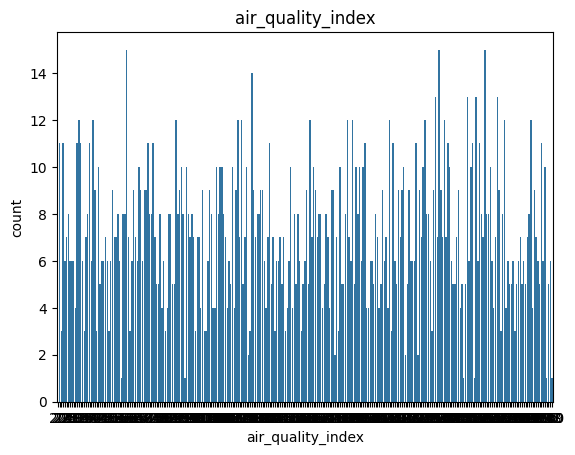

In [ ]:
sns.countplot(x='air_quality_index', data=df)
plt.title('air_quality_index')
plt.show()

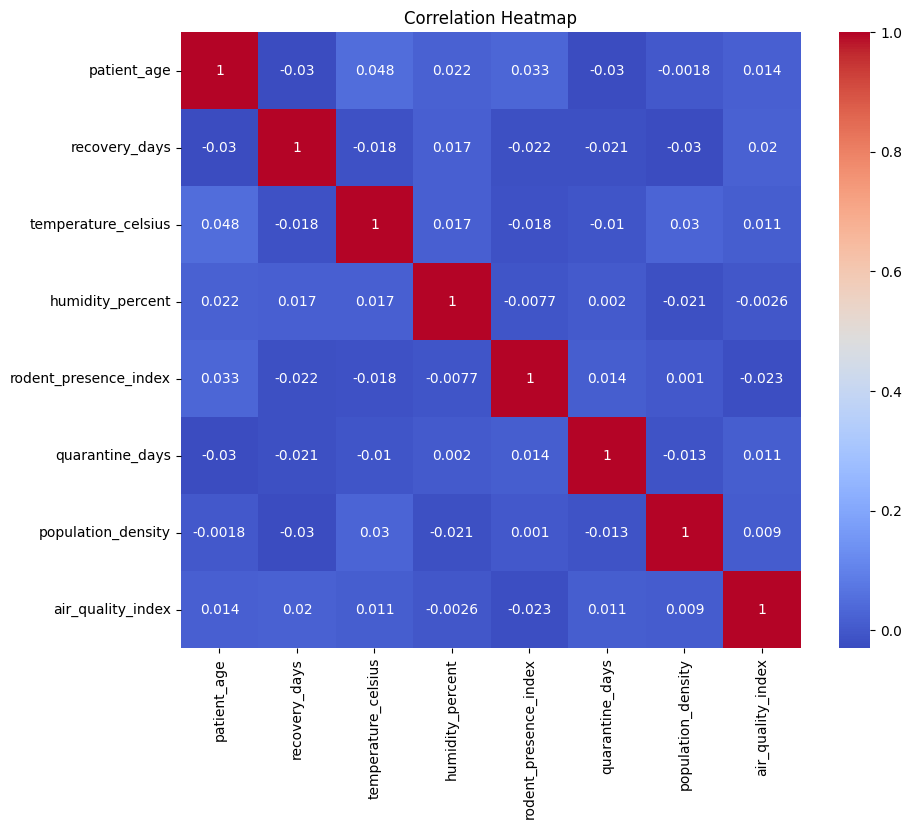

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()


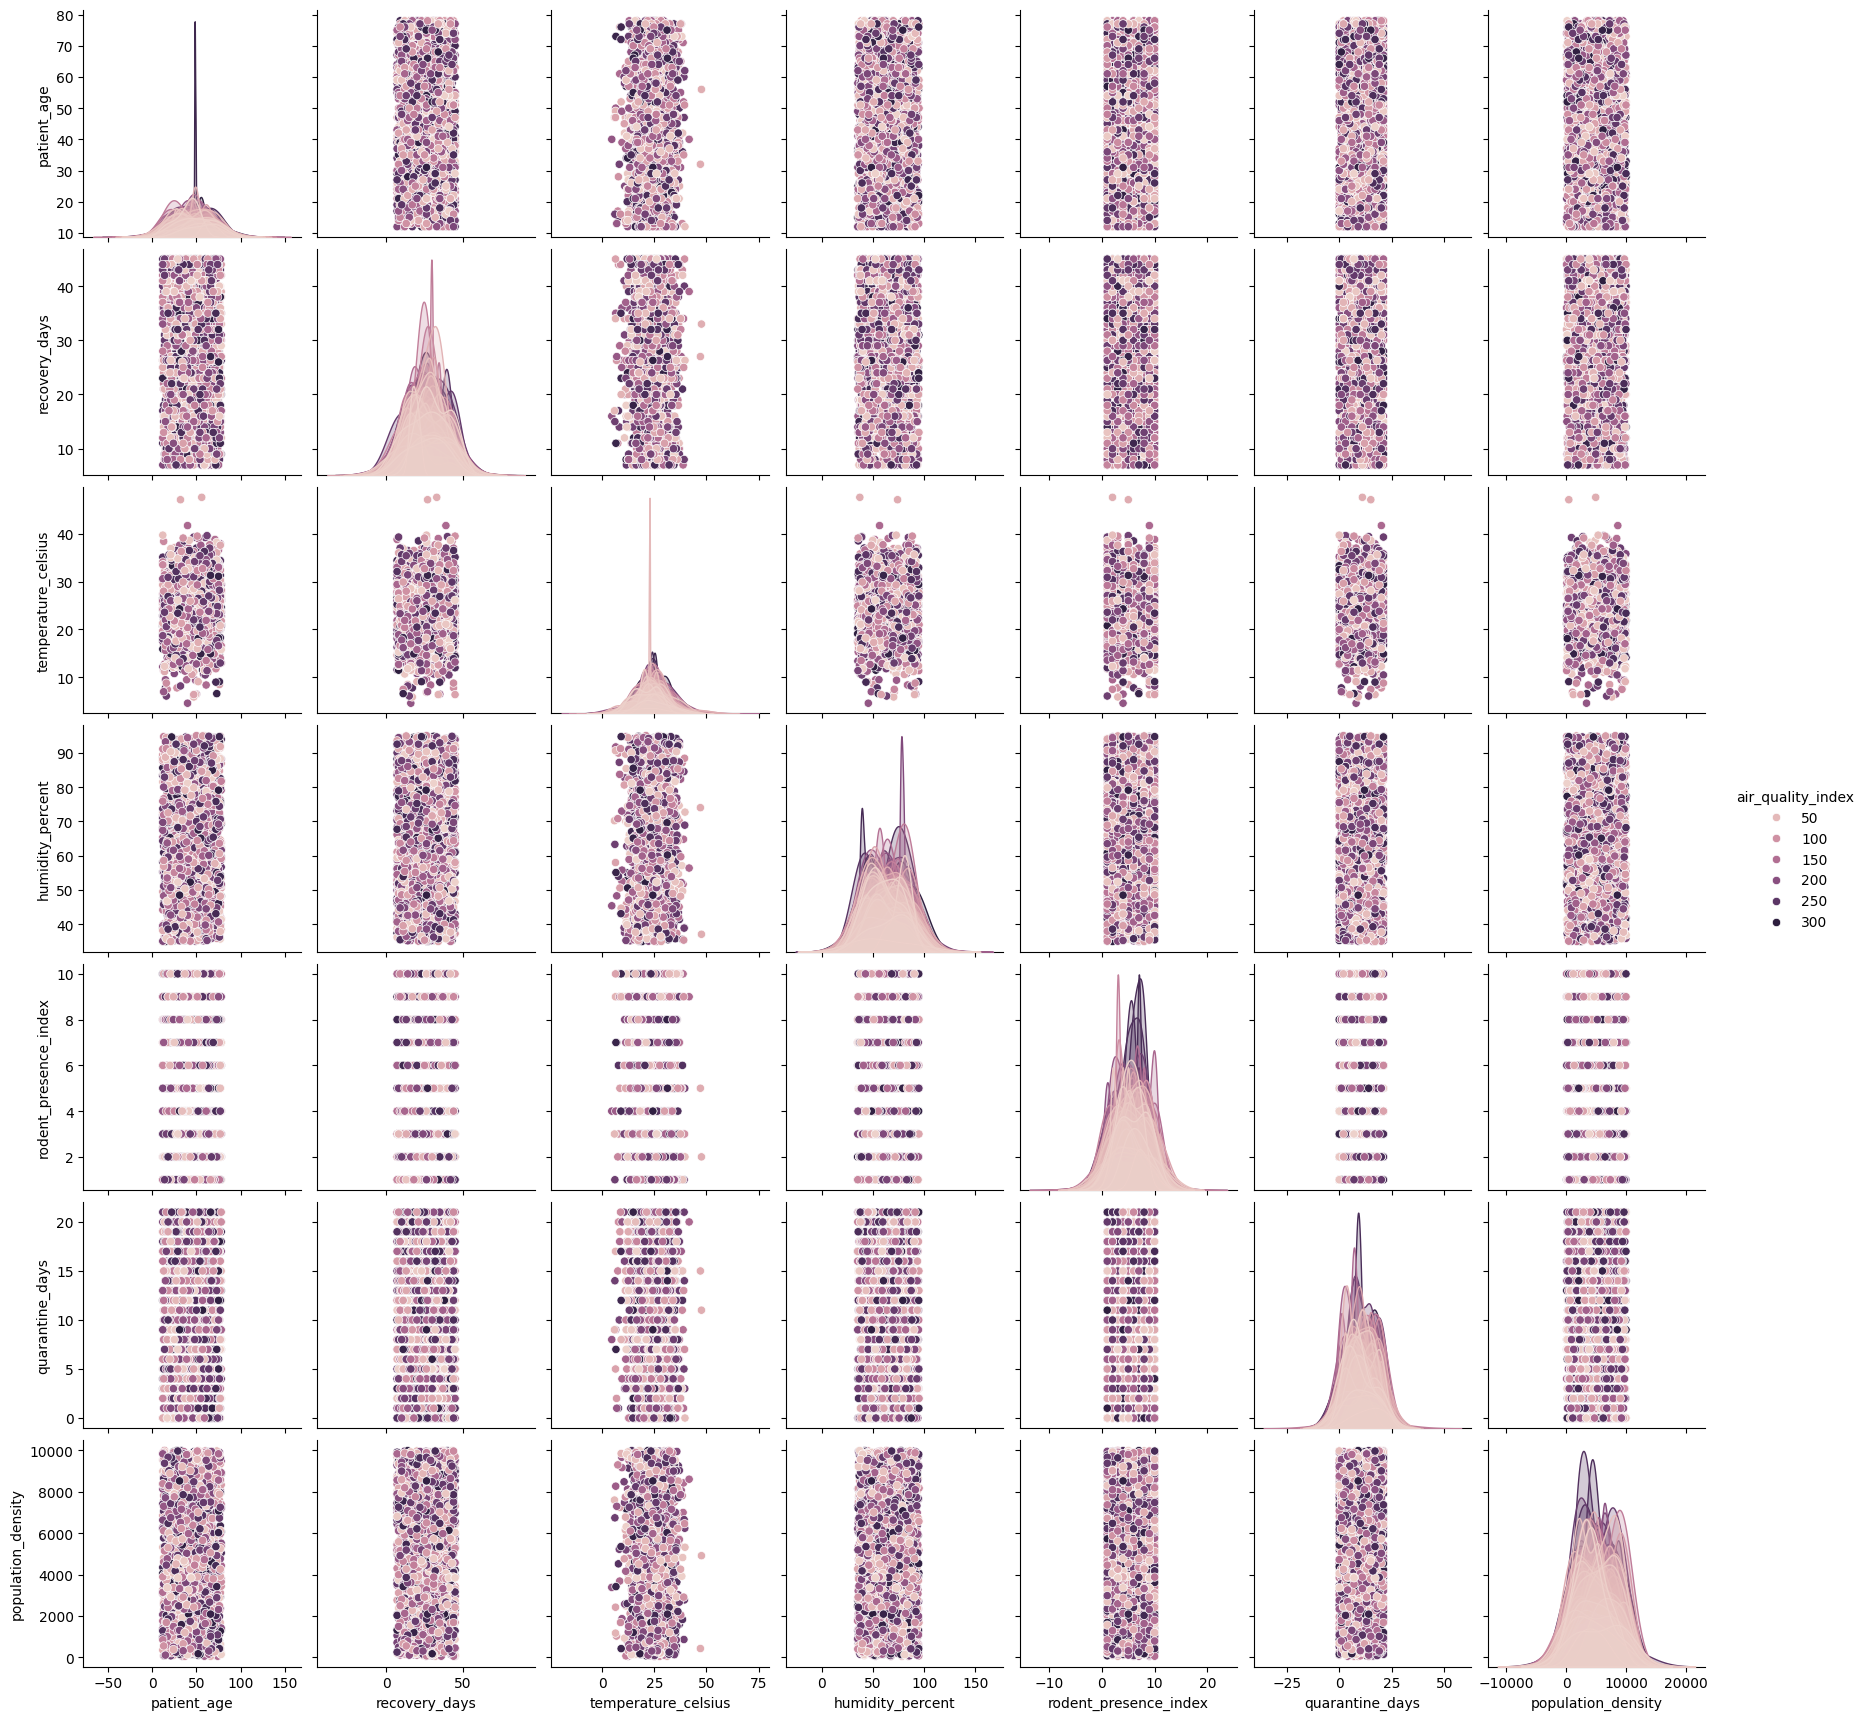

In [ ]:
sns.pairplot(df, hue='air_quality_index')
plt.show()

In [ ]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df['case_id'] = le.fit_transform(df['case_id'])
df['country'] = le.fit_transform(df['country'])
df['region'] = le.fit_transform(df['region'])
df['report_date'] = le.fit_transform(df['report_date'])
df['virus_strain'] = le.fit_transform(df['virus_strain'])
df['transmission_type'] = le.fit_transform(df['transmission_type'])
df['exposure_source'] = le.fit_transform(df['exposure_source'])
df['gender'] = le.fit_transform(df['gender'])
df['symptoms'] = le.fit_transform(df['symptoms'])
df['hospitalization'] = le.fit_transform(df['hospitalization'])
df['fatality'] = le.fit_transform(df['fatality'])

In [ ]:
X = df[['country', 'region', 'report_date',
        'virus_strain', 'transmission_type',
        'exposure_source']]

y = df['fatality']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[362   7]
 [ 30   1]]


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf','linear']
}

In [ ]:
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2 )

In [ ]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'linear']},
             verbose=2)

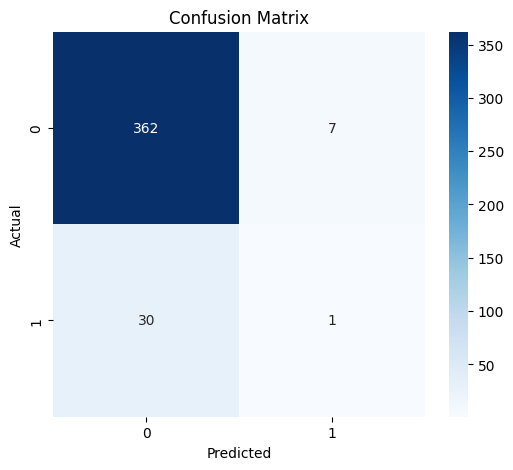

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       369
           1       0.12      0.03      0.05        31

    accuracy                           0.91       400
   macro avg       0.52      0.51      0.50       400
weighted avg       0.86      0.91      0.88       400



In [ ]:
accuracy_scores = []

for i in range(1, 21):

    model = KNeighborsClassifier(n_neighbors=i)

    model.fit(X_train, y_train)

    pred_i = model.predict(X_test)

    score = accuracy_score(y_test, pred_i)

    accuracy_scores.append(score)
print(accuracy_scores)

[0.87, 0.92, 0.9075, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225, 0.9225]


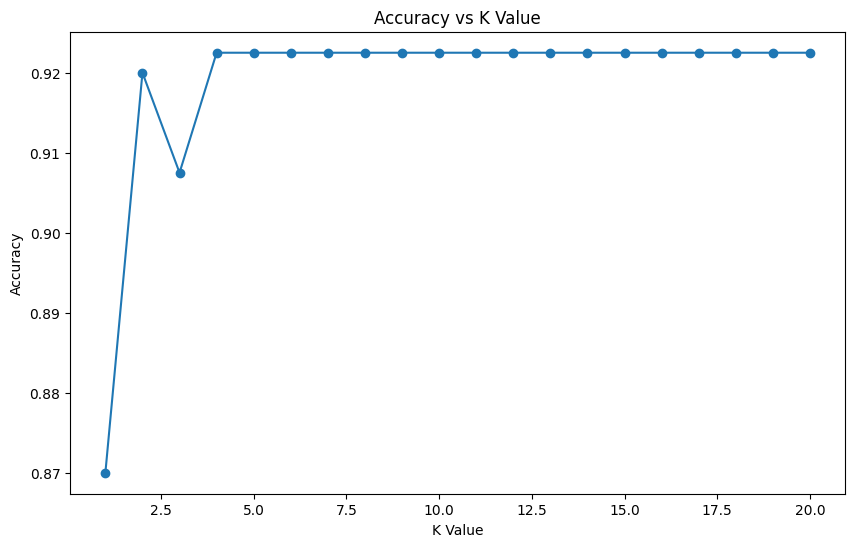

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracy_scores, marker='o', linestyle='-')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value')

plt.show()

In [ ]:
final_model = KNeighborsClassifier(n_neighbors=11)
final_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [ ]:
final_pred = final_model.predict(X_test)
print(final_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
final_accuracy = accuracy_score(y_test, final_pred)
print("Final Accuracy:", final_accuracy)

Final Accuracy: 0.9225


In [ ]:
df

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,0,3,718,390,4,1,0,26,1,3,1,0,22.0,27.0,78.9,7,1,538,67
1,1,1,271,350,4,0,3,41,0,2,1,0,41.0,23.2,70.9,3,13,5624,162
2,2,4,1387,332,3,0,3,39,0,2,0,0,31.0,22.6,38.5,8,17,2095,213
3,3,0,1781,152,4,0,4,49,1,2,0,0,11.0,22.6,87.0,7,8,7478,206
4,4,4,794,396,1,1,3,59,1,1,0,0,24.0,33.5,36.2,8,12,4472,132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,1,1523,183,0,1,3,43,0,4,0,0,30.0,25.9,71.6,2,2,9022,72
1996,1996,2,992,265,2,0,4,52,0,4,1,0,35.0,17.3,50.7,8,14,7014,67
1997,1997,5,197,310,1,0,5,64,0,3,0,0,24.0,23.8,60.1,3,19,309,210
1998,1998,6,1670,489,3,1,3,29,1,4,0,0,45.0,26.1,52.3,3,7,3843,21


In [ ]:
new_data = [[2, 845, 275, 3, 1, 2]]
new_data_scaled = scaler.transform(new_data)
prediction = final_model.predict(new_data_scaled)
print( prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
if prediction[0] == 0:
  print("Prediction is : recover")
elif prediction[0] == 1:
  print("Prediction is : Not recover")

Prediction is : recover
